# ML-09 — Validation Audit and One-Time Sealed Test

The primary metric and method were frozen before this notebook: Precision@50 selects the fixed transparent baseline; the random forest is the strongest learned comparison from validation. Before opening May→June, the claim is fixed: **the result is an observed out-of-time ranking test; whether it succeeds or fails, it will not prove a causal refresh effect or Google's mechanism, and it will not trigger sealed-month tuning.**

## 1. Frozen selection and development diagnostic

The receipt must show that selection used April→May only. A client-grouped validation diagnostic checks whether performance is broadly portable instead of coming from one large client; client identifiers are used for grouping but never displayed or modeled.

In [1]:
from pathlib import Path
import json
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

ROOT = Path.cwd().resolve()
while not (ROOT / 'work' / 'scripts').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from work.scripts.refresh_capstone import MODEL_FEATURES, baseline_score, build_candidate_pipelines, precision_at_k

selection = json.loads((ROOT / 'work' / 'outputs' / 'model_selection.json').read_text(encoding='utf-8'))
assert selection['selected_method'] == 'fixed_baseline'
assert selection['sealed_month_used'] is False
comparison_model = max(
    [x for x in selection['candidates'] if x['method'] != 'fixed_baseline'],
    key=lambda x: x['precision_at_50'],
)['method']
print('Frozen selected method:', selection['selected_method'])
print('Predeclared learned comparison:', comparison_model)
print('Frozen claim: out-of-time directional ranking evidence only; no causal or algorithm claim.')

mkdir -p failed for path C:\Users\hasan\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\hasan\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\hasan\AppData\Local\Temp\matplotlib-t5ru8by1 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Frozen selected method: fixed_baseline
Predeclared learned comparison: random_forest
Frozen claim: out-of-time directional ranking evidence only; no causal or algorithm claim.


## 2. Identical-row evaluation protocol

The learned comparison is refit on all development anchors through April after model choice, then applied once to May features predicting June. Baseline and forest receive the same eligible rows. Precision@50 is primary; average precision, Recall@50, Lift@50, and client-grouped average precision are supporting diagnostics.

In [2]:
cache = ROOT / 'work' / 'outputs' / 'model_examples.parquet'
con = duckdb.connect()
frames = con.execute("SELECT * FROM read_parquet(?) WHERE month BETWEEN DATE '2025-09-01' AND DATE '2026-05-01'", [str(cache)]).df()
development = frames.loc[pd.to_datetime(frames['month']).le('2026-04-01')].copy()
sealed = frames.loc[pd.to_datetime(frames['month']).eq('2026-05-01')].copy()
for frame in (development, sealed):
    frame['content_type'] = frame['content_type'].fillna('unknown').astype(str)
model = build_candidate_pipelines(random_seed=42)[comparison_model]
model.fit(development[list(MODEL_FEATURES)], development['future_decline'].astype(int))
sealed_scores = {
    'fixed_baseline': np.asarray(baseline_score(sealed)),
    comparison_model: model.predict_proba(sealed[list(MODEL_FEATURES)])[:, 1],
}
sealed_labels = sealed['future_decline'].to_numpy(dtype=int)
def metrics(labels, scores):
    order = np.argsort(-np.asarray(scores), kind='stable')[:50]
    p50 = precision_at_k(labels, scores, 50)
    base = float(np.mean(labels))
    return {
        'rows': int(len(labels)), 'positive_rate': base, 'precision_at_50': float(p50),
        'average_precision': float(average_precision_score(labels, scores)),
        'recall_at_50': float(np.asarray(labels)[order].sum() / np.asarray(labels).sum()),
        'lift_at_50': float(p50 / base),
    }
sealed_metrics = {name: metrics(sealed_labels, scores) for name, scores in sealed_scores.items()}
assert len({x['rows'] for x in sealed_metrics.values()}) == 1
display(pd.DataFrame(sealed_metrics).T)

,rows,positive_rate,precision_at_50,average_precision,recall_at_50,lift_at_50
fixed_baseline,93048.0,0.640401,0.68,0.670165,0.000571,1.061835
random_forest,93048.0,0.640401,0.98,0.722195,0.000822,1.530292


## 3. Grouped diagnostics, errors, and leakage checks

Macro client average precision summarizes performance across clients with both classes; it is diagnostic rather than a new selection metric. Error examples show safe aggregate features only. All preprocessing is fitted before sealed scoring, IDs are excluded, and no prediction feature comes from June.

In [3]:
def client_macro_ap(frame, scores):
    work = pd.DataFrame({'client': frame['client_hash_id'].astype(str), 'label': frame['future_decline'].to_numpy(), 'score': np.asarray(scores)})
    values = []
    for _, group in work.groupby('client', observed=True):
        if group['label'].nunique() == 2:
            values.append(average_precision_score(group['label'], group['score']))
    return {'eligible_clients': len(values), 'macro_average_precision': float(np.mean(values)) if values else None}
grouped = {name: client_macro_ap(sealed, scores) for name, scores in sealed_scores.items()}
selected_scores = sealed_scores['fixed_baseline']
top = np.argsort(-selected_scores, kind='stable')[:50]
analysis = sealed.reset_index(drop=True).copy()
analysis['score'] = selected_scores
analysis['top_50'] = analysis.index.isin(top)
errors = analysis.loc[analysis['top_50'] & analysis['future_decline'].eq(0)].head(8)
safe_columns = ['score', 'impressions', 'impression_momentum', 'avg_position', 'content_age_days', 'ctr', 'content_type']
display(pd.DataFrame(grouped).T)
display(errors[safe_columns])
assert {'client_hash_id', 'content_hash_id', 'future_decline', 'outcome_impressions'}.isdisjoint(MODEL_FEATURES)
assert sealed['outcome_month'].eq(pd.Timestamp('2026-06-01')).all()
print('Leakage audit passed; both methods used identical sealed rows and pre-outcome features.')

,eligible_clients,macro_average_precision
fixed_baseline,40.0,0.514838
random_forest,40.0,0.574931


,score,impressions,impression_momentum,avg_position,content_age_days,ctr,content_type
35834,79.784941,2609,0.114737,8.962438,309,0.002683,keyword article
40448,79.536062,2459,0.185431,12.028467,375,0.000407,keyword article
42422,78.484359,1936,0.154682,9.074380,324,0.003099,keyword article
57813,89.005243,17055,0.133146,10.855350,471,0.000000,keyword article
58140,78.593767,33589,0.481073,6.816309,471,0.000953,keyword article
66196,78.496537,680,0.135081,9.883824,471,0.002941,keyword article
75438,78.796062,1554,0.164305,9.122909,348,0.001287,keyword article
76681,78.821601,141364,0.463001,2.711638,436,0.002462,keyword article


Leakage audit passed; both methods used identical sealed rows and pre-outcome features.


## 4. Final result and honest claim

The validation-selected baseline remains the operational ranking even if the learned comparison changes order on the sealed month. The paper reports both outcomes, temporal variation, and the risk that demand shifts, data coverage, or seasonality—not content quality—drive the measured label.

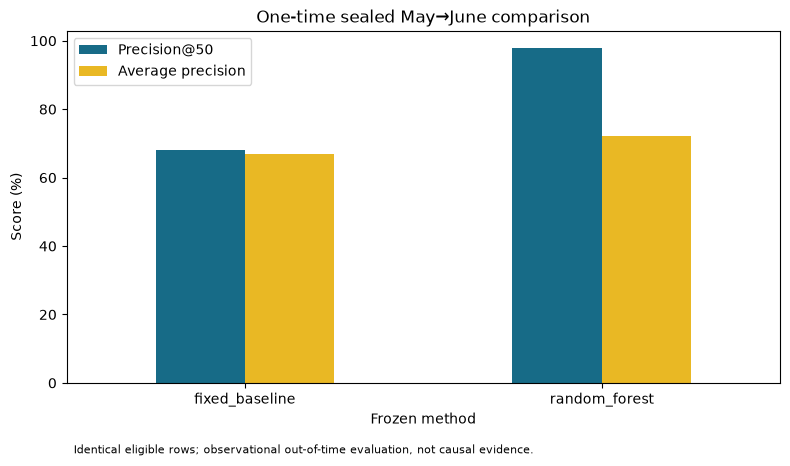

The learned comparison exceeded the validation-selected baseline on sealed Precision@50, showing temporal instability; the method is not retuned and claims remain directional.
Sealed evaluation recorded once; no sealed-month tuning was performed.


In [4]:
validation_metrics = {x['method']: x for x in selection['candidates']}
baseline_wins = sealed_metrics['fixed_baseline']['precision_at_50'] >= sealed_metrics[comparison_model]['precision_at_50']
claim = (
    'The validation-selected transparent baseline also matched or exceeded the learned comparison at sealed Precision@50; results remain directional decision support.'
    if baseline_wins else
    'The learned comparison exceeded the validation-selected baseline on sealed Precision@50, showing temporal instability; the method is not retuned and claims remain directional.'
)
final = {
    'selected_method': 'fixed_baseline', 'comparison_model': comparison_model,
    'primary_metric': 'precision_at_50', 'identical_rows': True,
    'validation': {name: {k: row[k] for k in ['rows', 'precision_at_50', 'average_precision', 'recall_at_50', 'lift_at_50']} for name, row in validation_metrics.items() if name in {'fixed_baseline', comparison_model}},
    'sealed': sealed_metrics, 'grouped_sealed_diagnostic': grouped,
    'claim_wording': claim, 'sealed_evaluated_once': True, 'sealed_anchor': '2026-05 predicting 2026-06',
    'limitations': ['temporal base-rate variation', 'observational label is not a causal refresh effect', 'coverage filters narrow applicability', 'content intent and seasonality are not fully represented'],
}
(ROOT / 'work' / 'outputs' / 'final_metrics.json').write_text(json.dumps(final, indent=2) + '\n', encoding='utf-8')
plot = pd.DataFrame({name: {'Precision@50': 100*x['precision_at_50'], 'Average precision': 100*x['average_precision']} for name, x in sealed_metrics.items()}).T
ax = plot.plot(kind='bar', figsize=(8, 4.8), color=['#176B87', '#E9B824'])
ax.set(title='One-time sealed May→June comparison', xlabel='Frozen method', ylabel='Score (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.text(.01, -.20, 'Identical eligible rows; observational out-of-time evaluation, not causal evidence.', transform=ax.transAxes, fontsize=8)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(ROOT / 'work' / 'figures' / 'sealed_month_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print(claim)
print('Sealed evaluation recorded once; no sealed-month tuning was performed.')

## Self-check

- [x] Method, primary metric, and claim boundary were frozen before sealed evaluation.
- [x] Baseline and model use identical validation and sealed populations.
- [x] Precision@50, average precision, Recall@50, Lift@50, and grouped diagnostics are recorded.
- [x] Leakage and safe-output assertions pass.
- [x] The result is reported without retuning or causal claims.